In [1]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if needed

# !pip install rank-bm25 sentence-transformers faiss-cpu

In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import faiss
import pickle
import numpy as np
import pandas as pd

from rank_bm25 import BM25Okapi

from sentence_transformers import SentenceTransformer

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# CELL 3 — CONFIG
# ============================================================

FAISS_INDEX_PATH = "../../parquet_exports_v2/incident_resolution.index"

EMBEDDING_METADATA_PATH = (
    "../../parquet_exports_v2/embedding_metadata.parquet"
)

BM25_CORPUS_PATH = (
    "../../parquet_exports_v2/bm25_corpus_v2.pkl"
)

EMBEDDING_MODEL_NAME = (
    "paraphrase-multilingual-MiniLM-L12-v2"
)

TOP_K_FAISS = 20
TOP_K_BM25 = 20

RRF_K = 60

print("=" * 60)
print("CONFIG")
print("=" * 60)

print(f"Embedding Model : {EMBEDDING_MODEL_NAME}")

print(f"FAISS Top K     : {TOP_K_FAISS}")

print(f"BM25 Top K      : {TOP_K_BM25}")

print(f"RRF Constant    : {RRF_K}")

CONFIG
Embedding Model : paraphrase-multilingual-MiniLM-L12-v2
FAISS Top K     : 20
BM25 Top K      : 20
RRF Constant    : 60


In [4]:
# ============================================================
# CELL 4 — LOAD FAISS INDEX
# ============================================================

index = faiss.read_index(
    FAISS_INDEX_PATH
)

print("=" * 60)
print("FAISS INDEX LOADED")
print("=" * 60)

print(f"Index Size : {index.ntotal:,}")

FAISS INDEX LOADED
Index Size : 109,875


In [5]:
# ============================================================
# CELL 5 — LOAD METADATA
# ============================================================

metadata_df = pd.read_parquet(
    EMBEDDING_METADATA_PATH
)

print("=" * 60)
print("METADATA LOADED")
print("=" * 60)

print(f"Rows    : {len(metadata_df):,}")
print(f"Columns : {metadata_df.shape[1]}")

metadata_df.head()

METADATA LOADED
Rows    : 109,875
Columns : 7


,chunk_id,document_id,rag_id,chunk_text,metadata_json,priority_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,[PROBLEM] i am unable to access my account aft...,"{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,2.3125
1,doc_1_chunk_0,doc_1,504f35fd3b03f048a1984f89fffb08e1,[PROBLEM] i would like to request a refund for...,"{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",3,1.5750
2,doc_2_chunk_0,doc_2,db7bc1e2f75fa986ee832c31e320a2de,[PROBLEM] there seems to be a discrepancy in m...,"{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",1,3.1250
3,doc_3_chunk_0,doc_3,01d7f2addbcc200f88368695230ea06e,[PROBLEM] the system is not syncing data acros...,"{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",2,2.6125
4,doc_4_chunk_0,doc_4,aa219338e9e467aadb53d3d1a9026de7,[PROBLEM] i am unable to access my account aft...,"{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",2,2.9500


In [6]:
# ============================================================
# CELL 6 — LOAD BM25 CORPUS
# ============================================================

bm25_tokens = pd.read_pickle(
    BM25_CORPUS_PATH
)

print("=" * 60)
print("BM25 CORPUS LOADED")
print("=" * 60)

print(f"Documents : {len(bm25_tokens):,}")

BM25 CORPUS LOADED
Documents : 109,875


In [7]:
# ============================================================
# CELL 7 — BUILD BM25 INDEX
# ============================================================

bm25 = BM25Okapi(
    bm25_tokens.tolist()
)

print("=" * 60)
print("BM25 INDEX CREATED")
print("=" * 60)

BM25 INDEX CREATED


In [8]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("=" * 60)
print("EMBEDDING MODEL LOADED")
print("=" * 60)

EMBEDDING MODEL LOADED


In [9]:
# ============================================================
# CELL 9 — BM25 SEARCH FUNCTION
# ============================================================

def bm25_search(
    query: str,
    top_k: int = 10
):

    tokenized_query = (
        query.lower().split()
    )

    scores = bm25.get_scores(
        tokenized_query
    )

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for rank, idx in enumerate(top_indices):

        row = metadata_df.iloc[idx]

        results.append({
            "retriever": "bm25",

            "rank": rank + 1,

            "score": float(scores[idx]),

            "chunk_id": row["chunk_id"],

            "text": row["chunk_text"]
        })

    return pd.DataFrame(results)


print("bm25_search function created.")

bm25_search function created.


In [10]:
# ============================================================
# CELL 10 — FAISS SEARCH FUNCTION
# ============================================================

def faiss_search(
    query: str,
    top_k: int = 10
):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(
        query_embedding,
        top_k
    )

    results = []

    for rank, (score, idx) in enumerate(
        zip(scores[0], indices[0])
    ):

        row = metadata_df.iloc[idx]

        results.append({
            "retriever": "faiss",

            "rank": rank + 1,

            "score": float(score),

            "chunk_id": row["chunk_id"],

            "text": row["chunk_text"]
        })

    return pd.DataFrame(results)


print("faiss_search function created.")

faiss_search function created.


In [11]:
# ============================================================
# CELL 11 — TEST INDIVIDUAL RETRIEVERS
# ============================================================

query = "VPN connection fails after password reset"

bm25_results = bm25_search(
    query=query,
    top_k=5
)

faiss_results = faiss_search(
    query=query,
    top_k=5
)

print("=" * 60)
print("BM25 RESULTS")
print("=" * 60)

display(bm25_results)

print("=" * 60)
print("FAISS RESULTS")
print("=" * 60)

display(faiss_results)

BM25 RESULTS


,retriever,rank,score,chunk_id,text
0,bm25,1,18.103690,doc_26012_chunk_0,[PROBLEM] vpn issue the marketing agency is cu...
1,bm25,2,16.266863,doc_89469_chunk_0,[PROBLEM] problems linking microsoft word vpn ...
2,bm25,3,15.157540,doc_86071_chunk_0,[PROBLEM] vpn connection issue team n nwe are ...
3,bm25,4,14.775751,doc_23420_chunk_0,[PROBLEM] digital campaign underperforming due...
4,bm25,5,12.851283,doc_71711_chunk_0,[PROBLEM] trouble with connection via vpn rout...


FAISS RESULTS


,retriever,rank,score,chunk_id,text
0,faiss,1,0.618192,doc_86071_chunk_0,[PROBLEM] vpn connection issue team n nwe are ...
1,faiss,2,0.596703,doc_37685_chunk_0,[PROBLEM] vpn access issue customer support n ...
2,faiss,3,0.553104,doc_103215_chunk_0,[PROBLEM] problem with vpn our marketing agenc...
3,faiss,4,0.543521,doc_42038_chunk_0,[PROBLEM] login problem with user accounts the...
4,faiss,5,0.536279,doc_23521_chunk_0,[PROBLEM] trouble with logins after recent sys...


In [12]:
# ============================================================
# CELL 12 — RECIPROCAL RANK FUSION
# ============================================================

def reciprocal_rank_fusion(
    result_frames,
    k: int = 60
):

    rrf_scores = {}

    text_lookup = {}

    for df in result_frames:

        for _, row in df.iterrows():

            chunk_id = row["chunk_id"]

            rank = row["rank"]

            score = 1 / (k + rank)

            if chunk_id not in rrf_scores:

                rrf_scores[chunk_id] = 0

            rrf_scores[chunk_id] += score

            text_lookup[chunk_id] = row["text"]

    fused_results = []

    for chunk_id, score in rrf_scores.items():

        fused_results.append({
            "chunk_id": chunk_id,

            "rrf_score": score,

            "text": text_lookup[chunk_id]
        })

    fused_df = pd.DataFrame(
        fused_results
    )

    fused_df = fused_df.sort_values(
        by="rrf_score",
        ascending=False
    )

    return fused_df.reset_index(drop=True)


print("RRF fusion function created.")

RRF fusion function created.


In [13]:
# ============================================================
# CELL 13 — HYBRID SEARCH FUNCTION
# ============================================================

def hybrid_search(
    query: str,
    top_k: int = 10
):

    bm25_df = bm25_search(
        query=query,
        top_k=top_k
    )

    faiss_df = faiss_search(
        query=query,
        top_k=top_k
    )

    fused_df = reciprocal_rank_fusion(
        [
            bm25_df,
            faiss_df
        ],
        k=RRF_K
    )

    return fused_df.head(top_k)


print("hybrid_search function created.")

hybrid_search function created.


In [14]:
# ============================================================
# CELL 14 — TEST HYBRID SEARCH
# ============================================================

query = "VPN connection fails after password reset"

hybrid_results = hybrid_search(
    query=query,
    top_k=10
)

print("=" * 60)
print("HYBRID SEARCH RESULTS")
print("=" * 60)

display(hybrid_results)

HYBRID SEARCH RESULTS


,chunk_id,rrf_score,text
0,doc_86071_chunk_0,0.032266,[PROBLEM] vpn connection issue team n nwe are ...
1,doc_26012_chunk_0,0.016393,[PROBLEM] vpn issue the marketing agency is cu...
2,doc_89469_chunk_0,0.016129,[PROBLEM] problems linking microsoft word vpn ...
3,doc_37685_chunk_0,0.016129,[PROBLEM] vpn access issue customer support n ...
4,doc_103215_chunk_0,0.015873,[PROBLEM] problem with vpn our marketing agenc...
5,doc_42038_chunk_0,0.015625,[PROBLEM] login problem with user accounts the...
6,doc_23420_chunk_0,0.015625,[PROBLEM] digital campaign underperforming due...
7,doc_71711_chunk_0,0.015385,[PROBLEM] trouble with connection via vpn rout...
8,doc_23521_chunk_0,0.015385,[PROBLEM] trouble with logins after recent sys...
9,doc_64943_chunk_0,0.015152,[PROBLEM] problem with login for user accounts...


In [15]:
# ============================================================
# CELL 15 — RETRIEVER COMPARISON
# ============================================================

print("=" * 60)
print("RETRIEVER COMPARISON")
print("=" * 60)

print("\nBM25 Top Result:")
print(
    bm25_results.iloc[0]["text"][:300]
)

print("\nFAISS Top Result:")
print(
    faiss_results.iloc[0]["text"][:300]
)

print("\nHYBRID Top Result:")
print(
    hybrid_results.iloc[0]["text"][:300]
)


RETRIEVER COMPARISON

BM25 Top Result:
[PROBLEM] vpn issue the marketing agency is currently aware of connection issues with the vpn router which is impacting our digital marketing strategy. these problems seem to arise from recent software updates affecting the network configuration. the router has already been restarted and the configu

FAISS Top Result:
[PROBLEM] vpn connection issue team n nwe are encountering a failure in vpn-router connectivity that is impacting several devices including essential remote telemedicine systems and emr integrations. despite rebooting the affected devices and attempting a router reset the problem remains unresolved.

HYBRID Top Result:
[PROBLEM] vpn connection issue team n nwe are encountering a failure in vpn-router connectivity that is impacting several devices including essential remote telemedicine systems and emr integrations. despite rebooting the affected devices and attempting a router reset the problem remains unresolved.


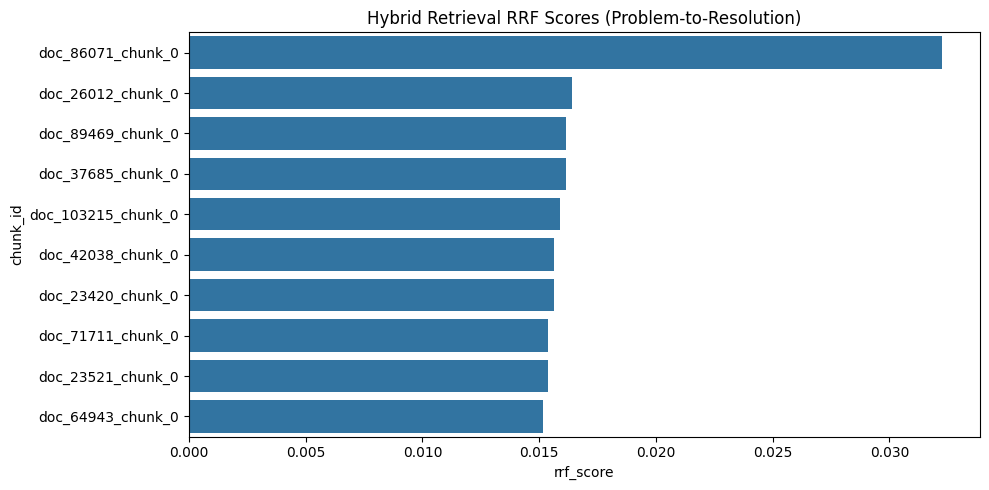

In [16]:
# ============================================================
# CELL 16 — VISUALIZE RRF SCORES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=hybrid_results.head(10),
    x="rrf_score",
    y="chunk_id"
)

plt.title("Hybrid Retrieval RRF Scores (Problem-to-Resolution)")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 17 — MULTI-QUERY EVALUATION
# ============================================================

test_queries = [
    "VPN connection fails after password reset",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "email synchronization problem"
]

evaluation_results = []

for query in test_queries:

    results = hybrid_search(
        query=query,
        top_k=5
    )

    evaluation_results.append({
        "query": query,

        "top_chunk_id": (
            results.iloc[0]["chunk_id"]
        ),

        "top_rrf_score": (
            results.iloc[0]["rrf_score"]
        )
    })

evaluation_df = pd.DataFrame(
    evaluation_results
)

print("=" * 60)
print("MULTI-QUERY EVALUATION")
print("=" * 60)

evaluation_df

MULTI-QUERY EVALUATION


,query,top_chunk_id,top_rrf_score
0,VPN connection fails after password reset,doc_86071_chunk_0,0.032266
1,outlook login issue,doc_80186_chunk_0,0.031778
2,printer not responding,doc_25854_chunk_0,0.032787
3,wifi connection unstable,doc_61437_chunk_0,0.016393
4,email synchronization problem,doc_107481_chunk_0,0.031258


In [18]:
# ============================================================
# CELL 18 — EXPORT HYBRID EVALUATION
# ============================================================

EXPORT_PATH = (
    "../../evaluation_v2/hybrid_retrieval_results_v2.csv"
)

evaluation_df.to_csv(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("EVALUATION EXPORTED")
print("=" * 60)

print(f"Path:\n{EXPORT_PATH}")

EVALUATION EXPORTED
Path:
../../evaluation_v2/hybrid_retrieval_results_v2.csv


In [19]:
# ============================================================
# CELL 19 — FINAL HYBRID RETRIEVAL REPORT
# ============================================================

print("=" * 60)
print("FINAL HYBRID RETRIEVAL REPORT")
print("=" * 60)

print(f"FAISS Index Size        : {index.ntotal:,}")

print(f"BM25 Corpus Size        : {len(bm25_tokens):,}")

print(f"Metadata Rows           : {len(metadata_df):,}")

print(f"RRF Constant            : {RRF_K}")

print(f"Embedding Model         : {EMBEDDING_MODEL_NAME}")

print(f"Average Hybrid Score    : {hybrid_results['rrf_score'].mean():.4f}")

FINAL HYBRID RETRIEVAL REPORT
FAISS Index Size        : 109,875
BM25 Corpus Size        : 109,875
Metadata Rows           : 109,875
RRF Constant            : 60
Embedding Model         : paraphrase-multilingual-MiniLM-L12-v2
Average Hybrid Score    : 0.0174
